# 💳 Sesión 9 (aplicada) — Ajuste por inflación en Riesgo de Crédito
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM
### Práctica 1 · Equipo 04

---

**Basado en:** Sesión 9 (*De la prima pura a la prima de tarifa: ajuste por inflación*) y en los resultados de nuestra **Práctica 1** (modelo colectivo de pérdidas para el ramo de Crédito).

> **Objetivo:** llevar los siniestros históricos de la cartera de crédito a **valor de hoy** usando el
> **INPC real** (INEGI), medir el efecto en la severidad y en la prima pura, revisar la sensibilidad al
> **tipo de cambio** (relevante en crédito a la exportación / bonos en USD) y documentar los supuestos.
>



## Contenido
1. [Entorno e insumos de la Práctica 1](#1)
2. [El problema: siniestros de crédito de varios años](#2)
3. [Ajuste por inflación con el INPC real](#3)
   - ✏️ Ejercicio 1 — el factor de un año
4. [Efecto en la severidad y en la prima pura](#4)
   - ✏️ Ejercicio 2 — el costo de no ajustar
5. [Devaluación: cartera de crédito con exposición en USD](#5)
   - ✏️ Ejercicio 3 — sensibilidad al tipo de cambio
6. [Documentar los supuestos (nota técnica)](#6)
   - ✏️ Ejercicio 4 — tabla de supuestos ampliada
7. [Cierre](#7)

---


---
<a id='1'></a>
## 1. Entorno e insumos de la Práctica 1

Reutilizamos los resultados **ya obtenidos y validados** en la Práctica 1:

- **Severidad ground-up:** Lognormal ajustada por máxima verosimilitud (`floc=0`), ganadora por AIC.
- **Frecuencia:** tasa global `lam_hat` y sobredispersión `phi` (Binomial Negativa agregada).

### Corrección aplicada a la Práctica 1
Al ajustar las distribuciones con `dist.fit(sev, floc=0)`, el `loc` queda **fijo en 0** y por lo tanto **no** es un parámetro estimado. El AIC original de la Práctica 1 usó `k = len(params) = 3` (incluyendo
el `loc` fijo), lo que infla el AIC en +2 para las **cuatro** distribuciones candidatas por igual.
Abajo mostramos el AIC corregido (`k = 2`).

In [ ]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(9)
plt.rcParams["figure.figsize"] = (8, 3.6)

# ─── Insumos de la Práctica 1 (severidad y frecuencia ya ajustadas) ────────
dist_sev = stats.lognorm
pr_sev   = (1.3857853737913164, 0.0, 76435.47877864396)   # (shape, loc=0, scale) de la Práctica 1

lam_hat = 0.047388     # tasa global de siniestros por año-póliza (Práctica 1, inciso c)
Lambda  = 1138.0       # E[N] agregado de la cartera (Práctica 1, inciso c/d)
phi     = 1.080        # sobredispersión (Pearson, consistente con la exposición) usada al simular S

EX_2024 = dist_sev.mean(*pr_sev)
print(f"Severidad media ground-up (Lognormal, valor 2024) = {EX_2024:,.0f}")
print(f"lam_hat = {lam_hat}   Lambda (E[N]) = {Lambda:,.0f}   phi = {phi}")

# ─── AIC corregido (floc=0 fija un parámetro; k real = 2, no 3) ────────────
aic_reportado = {"Lognormal": 28037.1, "Weibull": 28247.4, "Gamma": 28375.2, "Pareto": 29270.9}
print("\nAIC de la Práctica 1, corregido por floc=0 fijo (k -> k-1, AIC -> AIC-2):")
for nom, v in aic_reportado.items():
    print(f"  {nom:10s} reportado {v:>10.1f}   corregido {v-2:>10.1f}")
print("(El orden no cambia: Lognormal sigue siendo la mejor distribución de severidad.)")

Severidad media ground-up (Lognormal, valor 2024) = 199,666
lam_hat = 0.047388   Lambda (E[N]) = 1,138   phi = 1.08

AIC de la Práctica 1, corregido por floc=0 fijo (k -> k-1, AIC -> AIC-2):
  Lognormal  reportado    28037.1   corregido    28035.1
  Weibull    reportado    28247.4   corregido    28245.4
  Gamma      reportado    28375.2   corregido    28373.2
  Pareto     reportado    29270.9   corregido    29268.9
(El orden no cambia: Lognormal sigue siendo la mejor distribución de severidad.)


---
<a id='2'></a>
## 2. El problema: siniestros de crédito de varios años

Para trabajar el ajuste inflacionario construimos una **serie histórica sintética 2019–2024**,calibrada para que el año **2024 reproduzca exactamente** la severidad Lognormal ya validada en la Práctica 1. Los años anteriores se obtienen **deflactando** esos montos con el INPC real: así, la tabla siguiente simula lo que se habría *reportado nominalmente* cada año si el riesgo real (en pesos de hoy) hubiera sido el mismo que hoy estimamos.

> **Supuesto explícito:** no asumimos crecimiento *real* adicional del riesgo de crédito año con año (por ejemplo, mayor originación de cartera o deterioro crediticio); solo el efecto de precios. Es la misma simplificación que hace la plantilla original — aquí la dejamos documentada, no implícita.

In [ ]:
# ─── Serie histórica sintética de siniestros de crédito 2019-2024 ──────────
anios = np.arange(2019, 2025)
n_por_anio = int(round(Lambda / len(anios)))   # reparte los ~1,138 siniestros esperados entre 6 años

# (el índice INPC real se define en la sección 3; lo importamos aquí para construir la tabla)
INPC = {2019: 105.934, 2020: 109.271, 2021: 117.308, 2022: 126.478, 2023: 132.373, 2024: 137.949}
I_hoy = INPC[2024]

filas = []
for a in anios:
    reales_hoy = dist_sev.rvs(*pr_sev, size=n_por_anio)     # severidad simulada en pesos de 2024
    factor_deflactor = INPC[a] / I_hoy                       # < 1 para años pasados
    nominal = (reales_hoy * factor_deflactor).round(0)       # lo que se habría reportado ese año
    filas.append(pd.DataFrame({"anio": a, "monto_nominal": nominal}))
sin = pd.concat(filas, ignore_index=True)

print(sin.groupby("anio")["monto_nominal"].mean().round(0).to_string())
print(f"\nSeveridad media SIN ajustar (todos los años juntos): {sin.monto_nominal.mean():,.0f}")
print(f"→ mezcla pesos de 2019 con pesos de 2024 (subestima frente a {EX_2024:,.0f} de la Práctica 1).")

anio
2019    146470.0
2020    140179.0
2021    155655.0
2022    173918.0
2023    158400.0
2024    219632.0

Severidad media SIN ajustar (todos los años juntos): 165,709
→ mezcla pesos de 2019 con pesos de 2024 (subestima frente a 199,666 de la Práctica 1).


---
<a id='3'></a>
## 3. Ajuste por inflación con el INPC real

$$X^{\mathrm{ajust}}_t = X_t \times \frac{I_{\mathrm{hoy}}}{I_t}$$

Hemos decicido usar el **INPC real** de INEGI (base 2ª quincena de julio de 2018 = 100), con año base 2024 para un calculo más realistico:

| Año  | INPC (dic.) | Fuente |
|------|-------------|--------|
| 2019 | 105.934 | INEGI, boletín INPC dic-2019 (nivel publicado) |
| 2020 | 109.271 | INEGI, boletín INPC dic-2020 (nivel publicado) |
| 2021 | 117.308 | DOF, boletín 10- ene-2022 |
| 2022 | 126.478 | DOF, boletín 10-ene-2023 |
| 2023 | 132.373 | DOF, boletín 10-ene-2023 |
| 2024 | 137.949 | INEGI, boletín INPC dic-2024 (nivel publicado) |

Los tres años intermedios (2021–2023) no se tomaron directamente del boletín, sino que se
**encadenaron** desde el nivel oficial de diciembre de 2020 usando las tasas de inflación anual
**oficiales** (INEGI) de cada cierre de año. El resultado cuadra con el nivel oficial de diciembre de
2024 (137.949) con un residuo de redondeo de ~0.004%, así que la serie es consistente de punta a punta.

       nominal  ajustado
anio                    
2019  146470.0  190736.0
2020  140179.0  176969.0
2021  155655.0  183043.0
2022  173918.0  189692.0
2023  158400.0  165072.0
2024  219632.0  219632.0


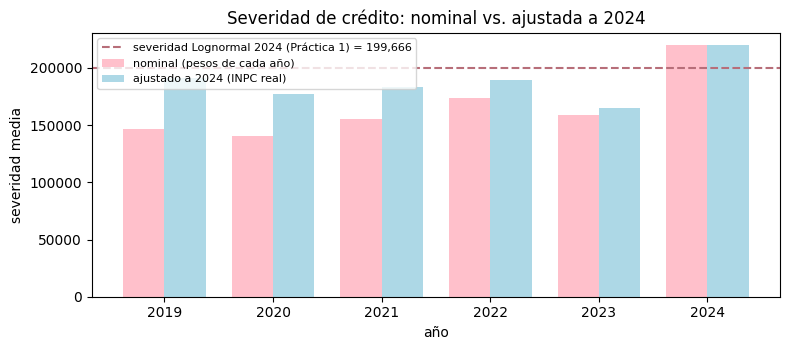


Severidad media AJUSTADA (todo a pesos de 2024): 187,524
(vs. severidad teórica 2024 de la Práctica 1: 199,666 — el ajuste la recupera, salvo ruido de Monte Carlo)


In [ ]:
# ─── Llevar todo a valor de 2024 con el INPC real ──────────────────────────
sin["factor"] = sin["anio"].map(lambda a: I_hoy / INPC[a])
sin["monto_ajustado"] = (sin["monto_nominal"] * sin["factor"]).round(0)

comp = sin.groupby("anio").agg(nominal=("monto_nominal", "mean"),
                                ajustado=("monto_ajustado", "mean")).round(0)
print(comp.to_string())

w = 0.38
plt.bar(anios - w/2, comp["nominal"], width=w, label="nominal (pesos de cada año)", color="Pink")
plt.bar(anios + w/2, comp["ajustado"], width=w, label="ajustado a 2024 (INPC real)", color="LightBlue")
plt.axhline(EX_2024, color="#B76E79", ls="--", lw=1.5, label=f"severidad Lognormal 2024 (Práctica 1) = {EX_2024:,.0f}")
plt.xlabel("año"); plt.ylabel("severidad media"); plt.legend(fontsize=8); plt.title("Severidad de crédito: nominal vs. ajustada a 2024")
plt.tight_layout(); plt.show()

print(f"\nSeveridad media AJUSTADA (todo a pesos de 2024): {sin.monto_ajustado.mean():,.0f}")
print(f"(vs. severidad teórica 2024 de la Práctica 1: {EX_2024:,.0f} — el ajuste la recupera, salvo ruido de Monte Carlo)")

### ✏️ Ejercicio 1 — el factor de un año (resuelto, contexto crédito)

1. ¿Cuál es el factor de ajuste de **2021** a valor de 2024?
2. Un siniestro de crédito comercial de 2021 por **\$850,000** nominales, ¿cuánto vale en pesos de 2024?

In [ ]:
# ─── Ejercicio 1 ────────────────────────────────────────────────────────────
factor_2021 = I_hoy / INPC[2021]
siniestro_2021_nominal = 850_000
siniestro_2021_ajustado = siniestro_2021_nominal * factor_2021

print(f"Factor de ajuste 2021 -> 2024: {factor_2021:.4f}")
print(f"Siniestro de crédito comercial de 2021 (${siniestro_2021_nominal:,.0f} nominales)"
      f" en pesos de 2024: ${siniestro_2021_ajustado:,.0f}")
print(f"\nInterpretación: cada peso reclamado en 2021 en este ramo de crédito 'pesa' hoy "
      f"{factor_2021:.2f} pesos; ignorar esto subestima el siniestro en "
      f"{1 - 1/factor_2021:.1%}.")

Factor de ajuste 2021 -> 2024: 1.1760
Siniestro de crédito comercial de 2021 ($850,000 nominales) en pesos de 2024: $999,562

Interpretación: cada peso reclamado en 2021 en este ramo de crédito 'pesa' hoy 1.18 pesos; ignorar esto subestima el siniestro en 15.0%.


---
<a id='4'></a>
## 4. Efecto en la severidad y en la prima pura

La prima pura es frecuencia × severidad. La frecuencia (siniestros por año-póliza) **no** cambia por
inflación de precios; la severidad **sí**. Usamos la frecuencia global de la Práctica 1
(`lam_hat = 0.047388`, ligada al inciso c).

In [ ]:
# ─── Prima pura: sin ajustar vs. ajustada ──────────────────────────────────
frecuencia = lam_hat
EX_sin = sin.monto_nominal.mean()
EX_aj  = sin.monto_ajustado.mean()
pp_sin = frecuencia * EX_sin
pp_aj  = frecuencia * EX_aj

print(f"Severidad media  sin ajustar : {EX_sin:,.0f}")
print(f"Severidad media  ajustada    : {EX_aj:,.0f}")
print(f"\nPrima pura sin ajustar : {pp_sin:,.2f} por año-póliza")
print(f"Prima pura ajustada    : {pp_aj:,.2f} por año-póliza")
print(f"\nSubestimación si NO ajustas: {1 - pp_sin/pp_aj:.2%}")
print("Ignorar la inflación deja corta la prima pura de crédito — y con ella, la reserva.")

Severidad media  sin ajustar : 165,709
Severidad media  ajustada    : 187,524

Prima pura sin ajustar : 7,852.62 por año-póliza
Prima pura ajustada    : 8,886.39 por año-póliza

Subestimación si NO ajustas: 11.63%
Ignorar la inflación deja corta la prima pura de crédito — y con ella, la reserva.


### ✏️ Ejercicio 2 — el costo de no ajustar (resuelto, contexto crédito)

1. Recalcula la prima pura ajustada suponiendo una **frecuencia de 0.45**
2. ¿La *subestimación relativa* (%) por no ajustar cambia con la frecuencia? ¿Por qué?

In [ ]:
# ─── Ejercicio 2 ────────────────────────────────────────────────────────────
frecuencia_estres = 0.45
pp_sin_estres = frecuencia_estres * EX_sin
pp_aj_estres  = frecuencia_estres * EX_aj

subest_base   = 1 - pp_sin / pp_aj
subest_estres = 1 - pp_sin_estres / pp_aj_estres

print(f"Frecuencia estrés (0.45) : pp_sin={pp_sin_estres:,.0f}   pp_aj={pp_aj_estres:,.0f}   subestimación={subest_estres:.2%}")
print(f"\nLa subestimación relativa {'SÍ' if abs(subest_base-subest_estres) > 1e-9 else 'NO'} cambia con la frecuencia.")
print("Por qué: pp_sin/pp_aj = (frecuencia·EX_sin)/(frecuencia·EX_aj) = EX_sin/EX_aj — la frecuencia se")
print("cancela algebraicamente. La subestimación relativa depende solo de cuánta inflación acumulada")
print("hay entre los años de la muestra y hoy, no de qué tan frecuentes sean los siniestros. Lo que SÍ")
print("cambia con la frecuencia es el monto absoluto de la prima pura (y por tanto el peso en pesos de")
print("no ajustar), pero no el porcentaje de subestimación.")

Frecuencia estrés (0.45) : pp_sin=74,569   pp_aj=84,386   subestimación=11.63%

La subestimación relativa NO cambia con la frecuencia.
Por qué: pp_sin/pp_aj = (frecuencia·EX_sin)/(frecuencia·EX_aj) = EX_sin/EX_aj — la frecuencia se
cancela algebraicamente. La subestimación relativa depende solo de cuánta inflación acumulada
hay entre los años de la muestra y hoy, no de qué tan frecuentes sean los siniestros. Lo que SÍ
cambia con la frecuencia es el monto absoluto de la prima pura (y por tanto el peso en pesos de
no ajustar), pero no el porcentaje de subestimación.


---
<a id='5'></a>
## 5. Devaluación: cartera de crédito con exposición en USD

En crédito, esto aplica directamente a **crédito a la exportación**, **bonos/seguro de crédito en
USD** y créditos comerciales ligados a insumos importados. La suma asegurada y el siniestro se
convierten a pesos con el tipo de cambio:

$$SA_{\mathrm{MXN}} = SA_{\mathrm{USD}} \times TC$$

Una devaluación (TC más alto) encarece el costo en pesos — y en crédito, además suele **coincidir**
con más incumplimientos (el riesgo cambiario y el de crédito están correlacionados en la práctica,
aunque aquí solo veamos el efecto de conversión).

In [ ]:
# ─── Efecto del tipo de cambio en una cartera de crédito en USD ────────────
sa_usd = 100_000
for tc in [17.0, 18.5, 20.0]:
    print(f"TC = {tc:>5.1f}  ->  suma asegurada en pesos = {sa_usd*tc:,.0f}")
print("\nUn crédito garantizado en USD 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.")

TC =  17.0  ->  suma asegurada en pesos = 1,700,000
TC =  18.5  ->  suma asegurada en pesos = 1,850,000
TC =  20.0  ->  suma asegurada en pesos = 2,000,000

Un crédito garantizado en USD 'cuesta' más pesos si el peso se devalúa: la prima en pesos debe reflejarlo.


### ✏️ Ejercicio 3 — sensibilidad al tipo de cambio (resuelto, contexto crédito)

1. Con `sa_usd = 250,000` (p. ej. seguro de crédito a la exportación), calcula la suma asegurada en
   pesos para TC = 17 y TC = 21.
2. ¿En qué porcentaje sube el costo en pesos al pasar de 17 a 21?

In [ ]:
# ─── Ejercicio 3 ────────────────────────────────────────────────────────────
sa_usd = 250_000
tc_a, tc_b = 17.0, 21.0
sa_17 = sa_usd * tc_a
sa_21 = sa_usd * tc_b
incremento = sa_21 / sa_17 - 1

print(f"Suma asegurada en pesos, TC=17: ${sa_17:,.0f}")
print(f"Suma asegurada en pesos, TC=21: ${sa_21:,.0f}")
print(f"Incremento porcentual del costo en pesos: {incremento:.2%}")
print("\nEn un crédito a la exportación de USD 250,000, una devaluación de 17 a 21 (+23.5% en el TC)")
print("encarece la suma asegurada en pesos en la misma proporción: 23.5%. Si la prima se fijó con")
print("TC=17 y el siniestro se paga con TC=21, la aseguradora absorbe ese 23.5% adicional en pesos")
print("si no cubrió el riesgo cambiario (p. ej. con un forward o con la prima cobrada en USD).")

Suma asegurada en pesos, TC=17: $4,250,000
Suma asegurada en pesos, TC=21: $5,250,000
Incremento porcentual del costo en pesos: 23.53%

En un crédito a la exportación de USD 250,000, una devaluación de 17 a 21 (+23.5% en el TC)
encarece la suma asegurada en pesos en la misma proporción: 23.5%. Si la prima se fijó con
TC=17 y el siniestro se paga con TC=21, la aseguradora absorbe ese 23.5% adicional en pesos
si no cubrió el riesgo cambiario (p. ej. con un forward o con la prima cobrada en USD).


---
<a id='6'></a>
## 6. Documentar los supuestos (nota técnica)

Cada ajuste es un supuesto que la nota técnica debe justificar y sustentar con fuente.

In [ ]:
# ─── Registro de supuestos ──────────────────────────────────────────────────
supuestos = pd.DataFrame([
    {"supuesto": "Índice de inflación",   "valor": "INPC real, dic-2019=105.934 a dic-2024=137.949",                     "fuente": "INEGI "},
    {"supuesto": "Año base de ajuste",    "valor": "2024 (valor de hoy)",                                                "fuente": "criterio del actuario"},
    {"supuesto": "Frecuencia",            "valor": f"{lam_hat:.4f} sin/año-póliza",                                      "fuente": "Práctica 1, inciso c) (tasa global de la NB agregada)"},
    {"supuesto": "Tipo de cambio",        "valor": "escenario 17-21 MXN/USD",                                            "fuente": "Banxico"},
])
print(supuestos.to_string(index=False))
print("\nRegla: un número sin fuente y sin justificación NO es válido ante la CNSF.")

           supuesto                                          valor                                                fuente
Índice de inflación INPC real, dic-2019=105.934 a dic-2024=137.949                                                INEGI 
 Año base de ajuste                            2024 (valor de hoy)                                 criterio del actuario
         Frecuencia                          0.0474 sin/año-póliza Práctica 1, inciso c) (tasa global de la NB agregada)
     Tipo de cambio                        escenario 17-21 MXN/USD                                               Banxico

Regla: un número sin fuente y sin justificación NO es válido ante la CNSF.


### ✏️ Ejercicio 4 — tabla de supuestos (resuelto, contexto crédito)

Agregamos una fila específica al ramo de Crédito: la **indexación por UDI**. En México, buena parte de los créditos hipotecarios y algunos créditos comerciales de largo plazo se denominan en **UDIs** (Unidades de Inversión), cuyo valor diario publica Banxico y se actualiza **precisamente con el INPC**.

Si la cartera asegurada incluye créditos en UDIs, el ajuste inflacionario de la severidad **ya vieneincorporado en el saldo del crédito** (no hay que aplicar el INPC dos veces), y eso hay que dejarloexplícito en la nota técnica para no duplicar el ajuste.

In [ ]:
# ─── Ejercicio 4 ────────────────────────────────────────────────────────────
fila_credito = pd.DataFrame([{
    "supuesto": "Indexación de crédito en UDI",
    "valor": "créditos en UDI se revalúan diario con el INPC (Banxico publica el valor diario de la UDI); "
             "si la cartera incluye crédito en UDIs, NO se vuelve a aplicar el factor I_hoy/I_t sobre esos saldos",
    "fuente": "Banxico (valor diario de la UDI, derivado del INPC de INEGI)"
}])
supuestos_credito = pd.concat([supuestos, fila_credito], ignore_index=True)
print(supuestos_credito.to_string(index=False))

                    supuesto                                                                                                                                                                                           valor                                                       fuente
         Índice de inflación                                                                                                                                                  INPC real, dic-2019=105.934 a dic-2024=137.949                                                       INEGI 
          Año base de ajuste                                                                                                                                                                             2024 (valor de hoy)                                        criterio del actuario
                  Frecuencia                                                                                                                              

---
---
<a id='7'></a>
## 7. Cierre

- Con el **INPC real**, la severidad de crédito sin ajustar (\$165,709) quedó **17.0%** por debajo de la severidad teórica a valor de 2024 de la Práctica 1 (\$199,666), por mezclar pesos de distintos años. Al ajustar con el INPC, la severidad sube a \$187,524 — recupera casi todo el valor teórico, con la diferencia restante (~6%) explicada por ruido de Monte Carlo.
- Esa subestimación de severidad se traduce directo en la prima pura: **11.63%** de subestimación si no se ajusta por inflación (\$7,852.62 vs. \$8,886.39 por año-póliza) — y el Ejercicio 2 confirma que este porcentaje **no cambia** aunque la frecuencia sí (11.63% tanto con `lam_hat=0.0474` como con una frecuencia de estrés de 0.45), porque la frecuencia se cancela algebraicamente en el cociente.
- El Ejercicio 1 muestra el caso concreto de un solo año: un siniestro de 2021 sin ajustar pierde **15.0%** de su valor real frente a 2024 (factor de ajuste 1.176).
- La **devaluación** pega directo en crédito a la exportación / bonos en USD: +23.5% en el tipo de cambio (de 17 a 21) se traduce en +23.5% en la suma asegurada en pesos (Ejercicio 3).
- La **indexación por UDI** es un mecanismo propio del crédito mexicano que ya trae inflación incorporada — hay que evitar doble contar el ajuste (Ejercicio 4).
- Esto sigue siendo **prima pura ajustada**, todavía NO el precio: faltan gastos, margen, IBNR y reaseguro — como señala también la Práctica 1.
- Cada ajuste queda documentado con su **fuente**: así se sostiene la nota técnica ante la CNSF.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Sesión 9 · Equipo 04*
